# ST446 Project: Exploratory Data Analysis

This notebook performs EDA on the cleaned flight delay dataset produced by `01-preprocessing.py`. 
It covers dataset structure, class distributions, temporal and airport-level delay patterns, 
delay cause breakdown, and feature-target correlations to motivate the two-layer classification approach.

## 1. Setup

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, mean, sum as spark_sum
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE = (10, 4)

In [3]:
spark = SparkSession.builder.appName("ST446-EDA").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("data/df_final_clean.parquet")
print(f"Rows: {df.count():,} | Columns: {len(df.columns)}")
df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/22 18:57:57 WARN Utils: Your hostname, MacBook-Pro-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.11.204 instead (on interface en0)
26/04/22 18:57:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 18:57:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 1:===============================================>           (4 + 1) / 5]

Rows: 3,480,548 | Columns: 17
root
 |-- carrier_id: integer (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- dep_hour: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- distance: double (nullable = true)
 |-- distance_group: integer (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- delay_carrier: integer (nullable = true)
 |-- delay_weather: integer (nullable = true)
 |-- delay_nas: integer (nullable = true)
 |-- delay_security: integer (nullable = true)
 |-- delay_late_aircraft: integer (nullable = true)
 |-- delay_none: integer (nullable = true)
 |-- delay_class: integer (nullable = true)



## 2. Dataset Overview

In [5]:
df.show(5, truncate=False)

+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+
|carrier_id|origin|dest|dep_hour|year|day_of_week|month|distance|distance_group|arr_delay|delay_carrier|delay_weather|delay_nas|delay_security|delay_late_aircraft|delay_none|delay_class|
+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+
|19393     |AUS   |ATL |6       |2022|7          |1    |813.0   |1             |-15.0    |0            |0            |0        |0             |0                  |1         |0          |
|19393     |AUS   |ATL |18      |2022|7          |1    |813.0   |1             |8.0      |0            |0            |0        |0             |0                  |0         |1          |
|19393     |BNA   |ATL |22      |2022|7          |1    |214.0   |

In [7]:
df.filter(df["year"] == 2018).show()


+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+
|carrier_id|origin|dest|dep_hour|year|day_of_week|month|distance|distance_group|arr_delay|delay_carrier|delay_weather|delay_nas|delay_security|delay_late_aircraft|delay_none|delay_class|
+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+
|     19393|   AUS| ATL|       6|2018|          5|    2|   813.0|             1|    -17.0|            0|            0|        0|             0|                  0|         1|          0|
|     19393|   AUS| ATL|      13|2018|          5|    2|   813.0|             1|     -6.0|            0|            0|        0|             0|                  0|         1|          0|
|     19393|   AUS| ATL|      17|2018|          5|    2|   813.0|

In [4]:
# Check for nulls across all columns
null_counts = df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
null_counts.show()

[Stage 5:===========>                                               (1 + 4) / 5]

+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+
|carrier_id|origin|dest|dep_hour|year|day_of_week|month|distance|distance_group|arr_delay|delay_carrier|delay_weather|delay_nas|delay_security|delay_late_aircraft|delay_none|delay_class|
+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+
|         0|     0|   0|       0|   0|          0|    0|       0|             0|        0|            0|            0|        0|             0|                  0|         0|          0|
+----------+------+----+--------+----+-----------+-----+--------+--------------+---------+-------------+-------------+---------+--------------+-------------------+----------+-----------+



In [5]:
# Summary statistics for numeric columns
numeric_cols = ["arr_delay", "distance", "dep_hour", "month", "day_of_week"]
df.select(numeric_cols).describe().show()

[Stage 8:===========>                                               (1 + 4) / 5]

+-------+------------------+-----------------+------------------+------------------+------------------+
|summary|         arr_delay|         distance|          dep_hour|             month|       day_of_week|
+-------+------------------+-----------------+------------------+------------------+------------------+
|  count|           3480548|          3480548|           3480548|           3480548|           3480548|
|   mean|2.9998049157776303|778.7572882201308|12.076041761239896| 6.631018736130057|3.9560327856418014|
| stddev| 55.15424093534746|600.0411116934673| 4.949972092653405|3.4436619050795114|1.9740660582959415|
|    min|            -114.0|             67.0|                 0|                 1|                 1|
|    max|            3423.0|           4983.0|                24|                12|                 7|
+-------+------------------+-----------------+------------------+------------------+------------------+



## 3. Target Variable: Two-Layer Classification

We adopt a hierarchical binary classification approach:
- **Layer 1**: On-time (arr_delay ≤ 15 min) vs Late (arr_delay > 15 min)
- **Layer 2**: Among late flights only — Minor delay (15–45 min) vs Major delay (> 45 min)

The 45-minute threshold for Layer 2 is chosen empirically: it sits at the median of the late-flight 
delay distribution, yielding a near-balanced split without resampling.

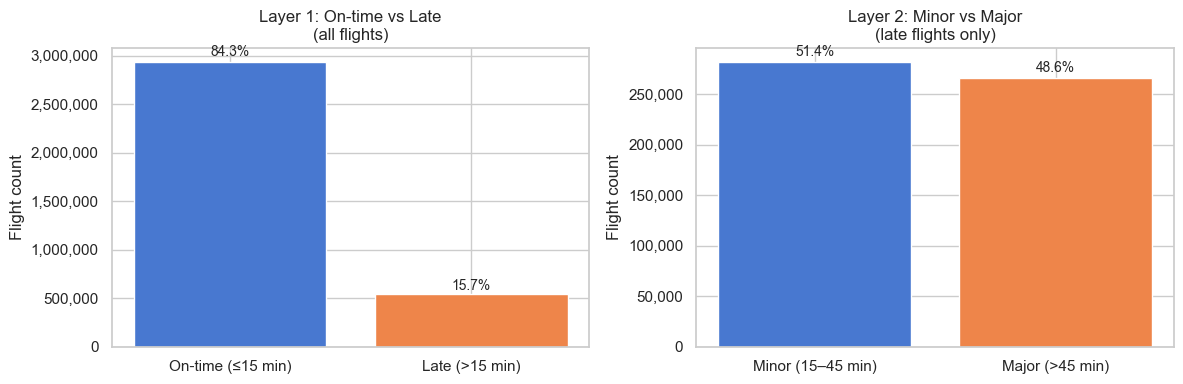

Layer 1:
            label   count       pct
On-time (≤15 min) 2933037 84.269402
   Late (>15 min)  547511 15.730598

Layer 2:
            label  count       pct
Minor (15–45 min) 281459 51.407004
  Major (>45 min) 266052 48.592996


In [6]:
# Derive two-layer target columns
df = df.withColumn("is_late", (col("arr_delay") > 15).cast("int"))
df = df.withColumn("delay_severity",
    when(col("arr_delay") <= 45, 0).otherwise(1))

# Layer 1 distribution
layer1 = df.groupBy("is_late").count().orderBy("is_late").toPandas()
layer1["label"] = layer1["is_late"].map({0: "On-time (≤15 min)", 1: "Late (>15 min)"})
layer1["pct"] = 100 * layer1["count"] / layer1["count"].sum()

# Layer 2 distribution (late flights only)
late_df = df.filter(col("is_late") == 1)
layer2 = late_df.groupBy("delay_severity").count().orderBy("delay_severity").toPandas()
layer2["label"] = layer2["delay_severity"].map({0: "Minor (15–45 min)", 1: "Major (>45 min)"})
layer2["pct"] = 100 * layer2["count"] / layer2["count"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(axes,
                            [layer1, layer2],
                            ["Layer 1: On-time vs Late\n(all flights)",
                             "Layer 2: Minor vs Major\n(late flights only)"]):
    bars = ax.bar(data["label"], data["count"], color=sns.color_palette("muted", 2))
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Flight count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, pct in zip(bars, data["pct"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("eda_class_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Layer 1:"); print(layer1[["label","count","pct"]].to_string(index=False))
print("\nLayer 2:"); print(layer2[["label","count","pct"]].to_string(index=False))

## 4. Arrival Delay Distribution

Understanding the shape of `arr_delay` motivates both the 15-minute on-time threshold and the 
45-minute severity split.

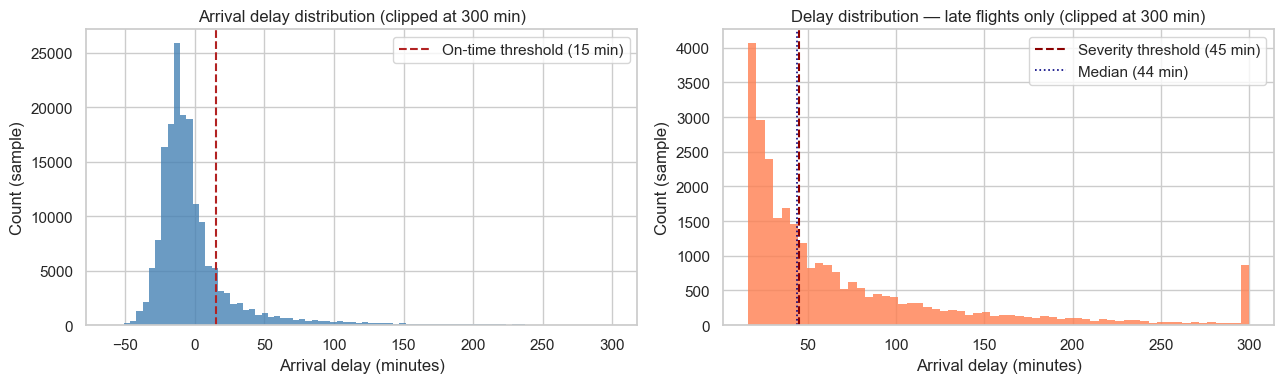

In [7]:
# Sample for plotting — 50k rows is enough to show the distribution
arr_delay_pd = df.select("arr_delay").sample(fraction=0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full range (clipped to remove extreme outliers for visual clarity)
clipped = arr_delay_pd[arr_delay_pd["arr_delay"].between(-60, 300)]
axes[0].hist(clipped["arr_delay"], bins=80, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(15, color="firebrick", linewidth=1.5, linestyle="--", label="On-time threshold (15 min)")
axes[0].set_title("Arrival delay distribution (clipped at 300 min)")
axes[0].set_xlabel("Arrival delay (minutes)")
axes[0].set_ylabel("Count (sample)")
axes[0].legend()

# Late flights only
late_pd = arr_delay_pd[arr_delay_pd["arr_delay"] > 15]
axes[1].hist(late_pd["arr_delay"].clip(upper=300), bins=60, color="coral", edgecolor="none", alpha=0.8)
axes[1].axvline(45, color="darkred", linewidth=1.5, linestyle="--", label="Severity threshold (45 min)")
axes[1].axvline(late_pd["arr_delay"].median(), color="navy", linewidth=1.2,
                linestyle=":", label=f'Median ({late_pd["arr_delay"].median():.0f} min)')
axes[1].set_title("Delay distribution — late flights only (clipped at 300 min)")
axes[1].set_xlabel("Arrival delay (minutes)")
axes[1].set_ylabel("Count (sample)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_arr_delay_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Temporal Patterns

Delay rates vary systematically by hour of day and by month, motivating `dep_hour` and `month` 
as features in both model layers.

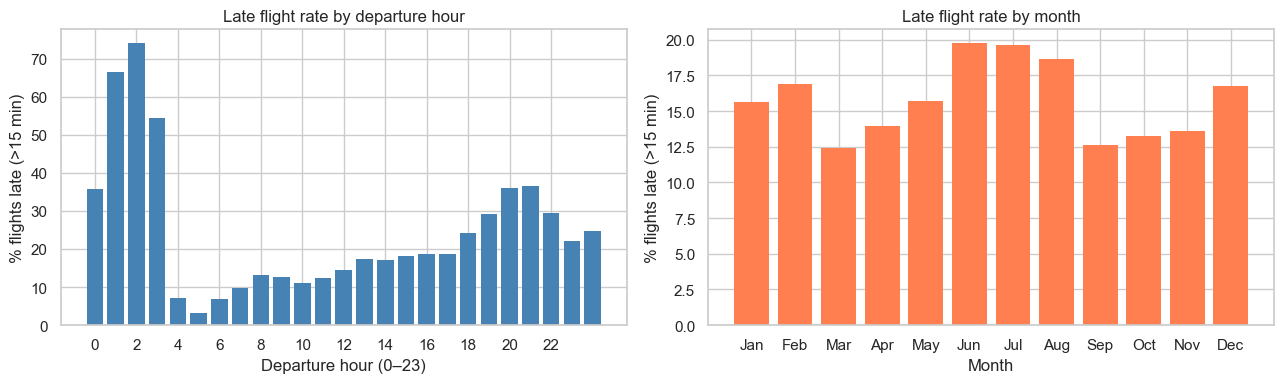

In [8]:
# Late rate by departure hour
hourly = (df.groupBy("dep_hour")
            .agg((spark_sum("is_late") / count("*") * 100).alias("late_pct"))
            .orderBy("dep_hour")
            .toPandas())

# Late rate by month
monthly = (df.groupBy("month")
             .agg((spark_sum("is_late") / count("*") * 100).alias("late_pct"))
             .orderBy("month")
             .toPandas())

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(hourly["dep_hour"], hourly["late_pct"], color="steelblue", edgecolor="none")
axes[0].set_title("Late flight rate by departure hour")
axes[0].set_xlabel("Departure hour (0–23)")
axes[0].set_ylabel("% flights late (>15 min)")
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(monthly["month"], monthly["late_pct"], color="coral", edgecolor="none")
axes[1].set_title("Late flight rate by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("% flights late (>15 min)")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)

plt.tight_layout()
plt.savefig("eda_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

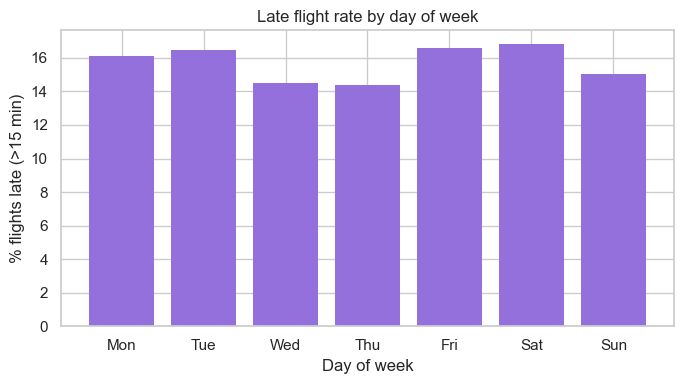

In [9]:
# Late rate by day of week
dow = (df.groupBy("day_of_week")
         .agg((spark_sum("is_late") / count("*") * 100).alias("late_pct"))
         .orderBy("day_of_week")
         .toPandas())

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dow["day_of_week"], dow["late_pct"], color="mediumpurple", edgecolor="none")
ax.set_title("Late flight rate by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("% flights late (>15 min)")
ax.set_xticks(range(1, 8))
ax.set_xticklabels(dow_labels)
plt.tight_layout()
plt.savefig("eda_dow_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Airport-Level Breakdown

Delay rates differ across the three hub airports, justifying `origin` (destination airport) 
as a feature rather than training separate per-airport models.

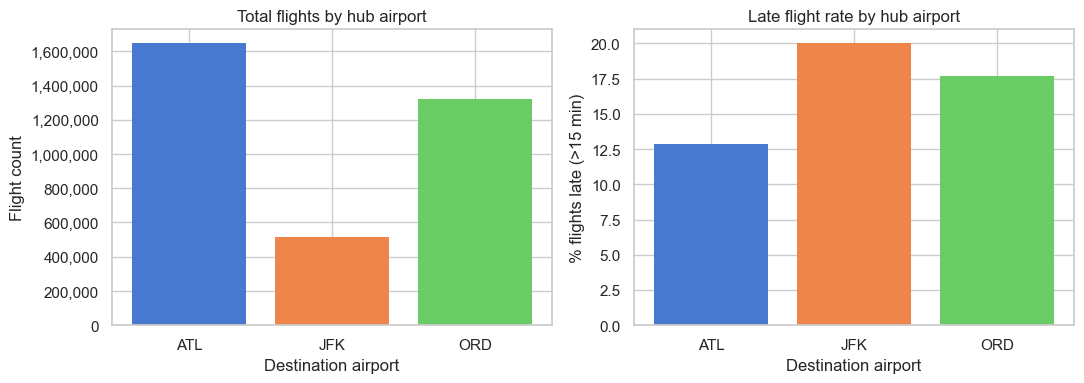

dest   total  late_pct
 ATL 1645627 12.832738
 JFK  516338 19.994267
 ORD 1318583 17.677613


In [10]:
# Late rate by destination airport (ORD, JFK, ATL)
by_dest = (df.groupBy("dest")
             .agg(
                 count("*").alias("total"),
                 (spark_sum("is_late") / count("*") * 100).alias("late_pct")
             )
             .filter(col("dest").isin(["ORD", "JFK", "ATL"]))
             .orderBy("dest")
             .toPandas())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(by_dest["dest"], by_dest["total"], color=sns.color_palette("muted", 3), edgecolor="none")
axes[0].set_title("Total flights by hub airport")
axes[0].set_ylabel("Flight count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].bar(by_dest["dest"], by_dest["late_pct"], color=sns.color_palette("muted", 3), edgecolor="none")
axes[1].set_title("Late flight rate by hub airport")
axes[1].set_ylabel("% flights late (>15 min)")
for ax in axes:
    ax.set_xlabel("Destination airport")

plt.tight_layout()
plt.savefig("eda_airport_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print(by_dest.to_string(index=False))

## 7. Delay Cause Breakdown

The binary delay cause columns (`delay_carrier`, `delay_weather`, `delay_nas`, `delay_security`, 
`delay_late_aircraft`) describe *why* a flight was delayed. These columns are only non-zero when 
a delay occurred, which creates a data leakage risk if used as features directly — a point 
addressed in the feature engineering step.

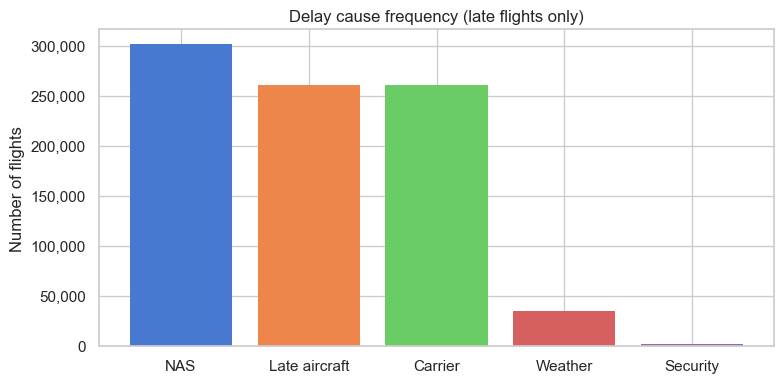

        label  count
          NAS 301213
Late aircraft 260779
      Carrier 260749
      Weather  34756
     Security   2010


In [11]:
cause_cols = ["delay_carrier","delay_weather","delay_nas","delay_security","delay_late_aircraft"]
cause_labels = ["Carrier","Weather","NAS","Security","Late aircraft"]

# Among late flights only
cause_counts = (late_df
                .select([spark_sum(c).alias(c) for c in cause_cols])
                .toPandas()
                .T
                .reset_index())
cause_counts.columns = ["cause","count"]
cause_counts["label"] = cause_labels
cause_counts = cause_counts.sort_values("count", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cause_counts["label"], cause_counts["count"],
       color=sns.color_palette("muted", len(cause_cols)), edgecolor="none")
ax.set_title("Delay cause frequency (late flights only)")
ax.set_ylabel("Number of flights")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("eda_delay_causes.png", dpi=150, bbox_inches="tight")
plt.show()
print(cause_counts[["label","count"]].to_string(index=False))

## 8. Carrier-Level Delay Rates

Late rates vary across carriers, confirming `carrier_id` as an informative feature.

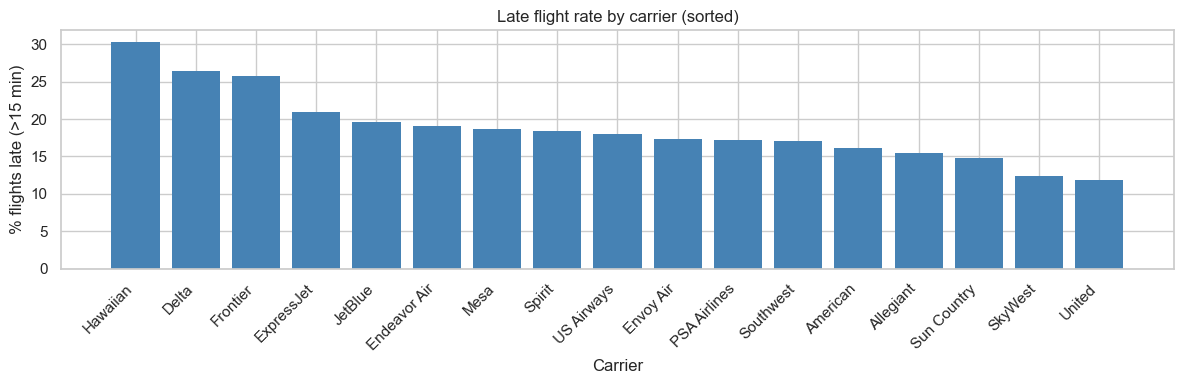

     Carrier Total Flights Late Rate (%)
    Hawaiian         1,433         30.4%
       Delta        33,202         26.4%
    Frontier       196,692         25.7%
  ExpressJet        36,500         21.0%
     JetBlue        80,816         19.6%
Endeavor Air       334,326         19.0%
        Mesa         9,930         18.7%
      Spirit        33,651         18.4%
  US Airways       357,759         18.1%
   Envoy Air       249,658         17.3%
PSA Airlines         9,314         17.2%
   Southwest       182,809         17.1%
    American       321,425         16.2%
   Allegiant         1,205         15.5%
 Sun Country       164,488         14.8%
     SkyWest       281,128         12.4%
      United     1,185,733         11.8%


In [12]:
# DOT carrier ID to airline name mapping
carrier_names = {
    19393: "Southwest",
    19687: "Alaska",
    19690: "Hawaiian",
    19790: "United",
    19805: "US Airways",
    19930: "Spirit",
    19977: "American",
    20304: "Endeavor Air",
    20363: "SkyWest",
    20366: "ExpressJet",
    20378: "Mesa",
    20397: "PSA Airlines",
    20398: "Envoy Air",
    20409: "Frontier",
    20416: "JetBlue",
    20436: "Delta",
    20452: "Sun Country",
    21171: "Allegiant"
}

by_carrier = (df.groupBy("carrier_id")
                .agg(
                    count("*").alias("total"),
                    (spark_sum("is_late") / count("*") * 100).alias("late_pct")
                )
                .filter(col("total") > 1000)
                .orderBy("late_pct", ascending=False)
                .toPandas())

by_carrier["name"] = by_carrier["carrier_id"].map(carrier_names)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_carrier["name"], by_carrier["late_pct"],
       color="steelblue", edgecolor="none")
ax.set_title("Late flight rate by carrier (sorted)")
ax.set_xlabel("Carrier")
ax.set_ylabel("% flights late (>15 min)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_carrier_rates.png", dpi=150, bbox_inches="tight")
plt.show()

summary_table = by_carrier[["name", "total", "late_pct"]].copy()
summary_table.columns = ["Carrier", "Total Flights", "Late Rate (%)"]
summary_table["Total Flights"] = summary_table["Total Flights"].apply(lambda x: f"{x:,}")
summary_table["Late Rate (%)"] = summary_table["Late Rate (%)"].apply(lambda x: f"{x:.1f}%")
summary_table = summary_table.reset_index(drop=True)
print(summary_table.to_string(index=False))

## 9. Feature–Target Correlation

A correlation heatmap between numeric features and `is_late`. Note that the delay cause 
binary flags will show high correlation — this is expected given the leakage discussed above, 
and they will be excluded from the model feature set.

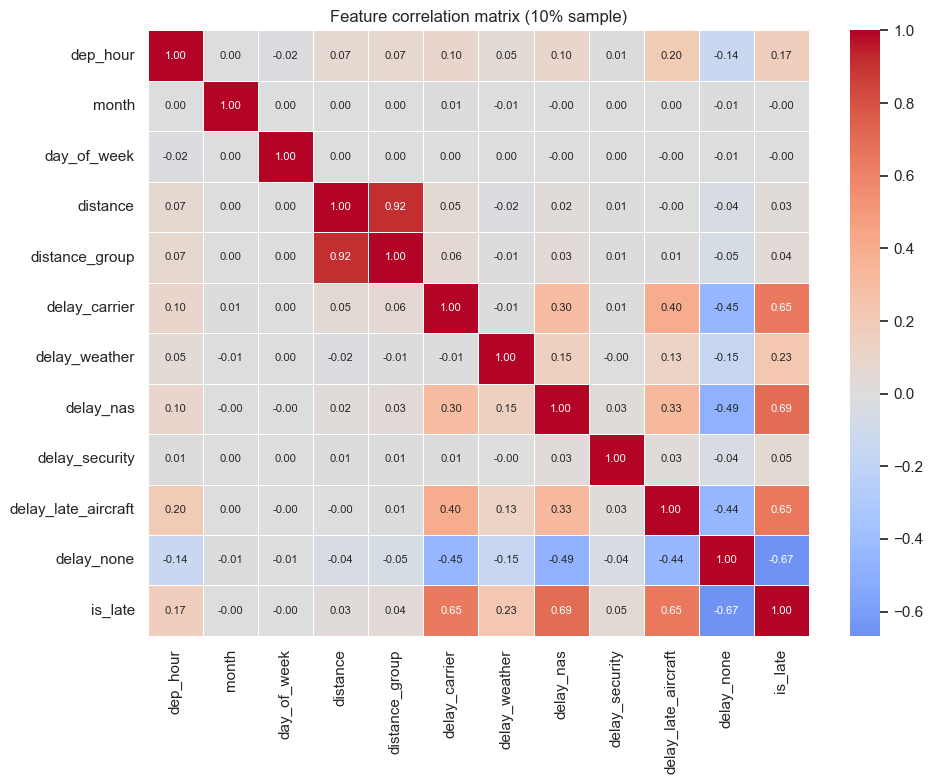

In [13]:
corr_cols = ["dep_hour","month","day_of_week","distance","distance_group",
             "delay_carrier","delay_weather","delay_nas","delay_security",
             "delay_late_aircraft","delay_none","is_late"]

# Sample to keep pandas workable
corr_pd = df.select(corr_cols).sample(fraction=0.1, seed=42).toPandas()
corr_matrix = corr_pd.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature correlation matrix (10% sample)")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Distance and Delay

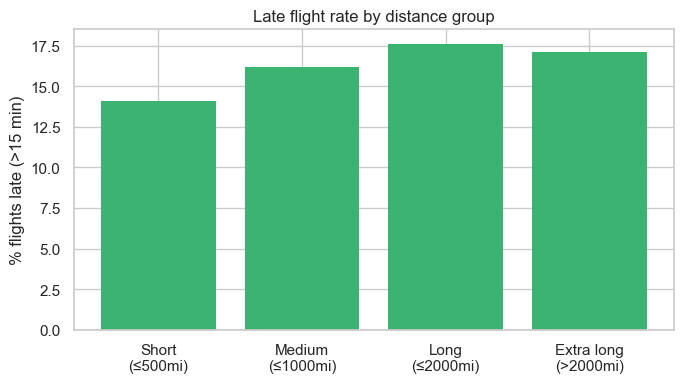

                label   total  late_pct
      Short\n(≤500mi) 1270531 14.083167
    Medium\n(≤1000mi) 1409361 16.210822
      Long\n(≤2000mi)  604828 17.626664
Extra long\n(>2000mi)  195828 17.106849


In [14]:
# Late rate by distance group
by_dist = (df.groupBy("distance_group")
             .agg((spark_sum("is_late") / count("*") * 100).alias("late_pct"),
                  count("*").alias("total"))
             .orderBy("distance_group")
             .toPandas())

dist_labels = {0: "Short\n(≤500mi)", 1: "Medium\n(≤1000mi)",
               2: "Long\n(≤2000mi)", 3: "Extra long\n(>2000mi)"}
by_dist["label"] = by_dist["distance_group"].map(dist_labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_dist["label"], by_dist["late_pct"], color="mediumseagreen", edgecolor="none")
ax.set_title("Late flight rate by distance group")
ax.set_ylabel("% flights late (>15 min)")
plt.tight_layout()
plt.savefig("eda_distance_delay.png", dpi=150, bbox_inches="tight")
plt.show()
print(by_dist[["label","total","late_pct"]].to_string(index=False))

## 11. Summary of Key EDA Findings

Key points from the EDA to carry into modelling:

2 Layer Classification Problem:
+ Layer 1: On-Time (Within 15 min of Arrival Time) vs. Late
- Distribution of 84.3% on-time (2,933,037) and 15.7% late (547,511)
- Severe imbalance for this classification
- Approximately normal distribution with heavy right skew

+ Layer 2: Minor (15 to 45 min late) vs. Major Late Arrivals
- Distribution of 51.4% minor (281,459) and 48.6% major (266,052)
- Great balance between these classes
- Approximately Exponential for raw delay values, roughly uniform after the split

Temporal Patterns:
Beginning around 4AM, the percentage of delayed flights increases on a daily rotation, peaking at 2AM with more than 70% of flights being delayed.

The summer months have the highest rate of delayed flights, with about 18-20% of flights being delayed. The winter season is a close second. Fall and Spring have the least amount of delays.

Wednesday and Thursday have the lowest day of week delay rate, Tuesday, Friday, and Saturday have the most.

Airport Breakdown:
ATL has the most flights (\~1.65 million) followed by ORD (\~1.32 million) and JFK (\~520k). JFK has the highest delay rate (20%) followed by ORD (17.7%) and ATL (12.8%).

Delay Causes:
NAS (National Airspace System), late aircraft, and carrier issues are the leading causes of delayed flights.
*Disclaimer: The five binary delay cause columns are excluded from model features as they are only observable post-departure, and including them would constitute data leakage.*

Carrier Specific delays:
Hawaiian, Delta, and Frontier lead the delay rate, with all 3 being over 25%. United had the least number of delays (12%) but the most flights by far (1.19 million).

Feature Correlation:
Not a strong correlation between many variables except for a semi-strong negative for the delay_none variable and the delay type variables. The reverse is true for is_late. This is expected.

By Flight Distance:
There is an increase in late rates as the flights get longer, but with a slight dip for extra long-haul flights (more than 2k miles). Long-haul flights likely have more scheduling buffer built in, which could explain it.

In [16]:
# THIS STAYS AT THE END
spark.stop()